In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import tensorflow as tf

from plotly.subplots import make_subplots
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

import plotly.io as pio

pio.renderers.default = 'jupyterlab'

# Importamos esta librería para solventar el problema que podáis tener para visualizar gráficos con Plotly
from IPython.display import HTML

## CARGA DE DATOS CSV

In [89]:
IF_PLOTLY_FAILS = False
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"

df_hotel = pd.read_csv(CSV_HOTEL_PATH)

## PREPROCESAMIENTO DE DATOS

In [90]:
# Generamos una copia de los datos en crudo para tener siempre un punto de referencia de partida.
df_hotel_prep = df_hotel.copy()

df_hotel_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [91]:
# Transformamos vars categóricas a tipo 'category'
# dict_hotel_cast_category_cols = {
#     'hotel': 'str',
#     'arrival_date_year': 'str',
#     'arrival_date_month': 'str',
#     'arrival_date_week_number': 'str',
#     'arrival_date_day_of_month': 'str',
#     'distribution_channel': 'str',
#     'market_segment': 'str',
#     'meal': 'str',
#     'country: 'str',
#     'is_repeated_guest': 'str',
#     'reserved_room_type': 'str',
#     'assigned_room_type': 'str',
#     'deposit_type': 'str',
#     'customer_type': 'str',
#     'reservation_status': 'str',
#     'reservation_status_date': 'str'
# }

dict_hotel_cast_category_cols = {
    'arrival_date_month': 'str',
    'hotel': 'str',
    'distribution_channel': 'str',
    'market_segment': 'str',
    'meal': 'str',
    'country': 'str',
    'reserved_room_type': 'str',
    'assigned_room_type': 'str',
    'deposit_type': 'str',
    'customer_type': 'str'
}

df_hotel_prep = df_hotel_prep.astype(dict_hotel_cast_category_cols)

df_hotel_prep.T

df_hotel_prep.country.hasnans


False

In [92]:
# Hiperparámetros
test_size = 0.2
random_state=42

target_column = 'is_canceled'
X = df_hotel_prep.drop(columns=[target_column])
y = df_hotel_prep[target_column]

print(f"Percentage y: {y.value_counts(normalize=True)}")

# Preparación de los datos para el entrenamiento del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

Percentage y: is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


In [93]:
# Definimos las columnas para cada tipo de transformación
#list_one_hot_cols = ['agent','company']
#list_ordinal_cols = ['hotel','arrival_date_year','arrival_date_month','arrival_date_week_number','arrival_date_day_of_month','distribution_channel','market_segment','meal','country','is_repeated_guest','reserved_room_type','assigned_room_type','deposit_type','customer_type','reservation_status','reservation_status_date']
list_ordinal_cols = ['arrival_date_month','hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
list_numeric_cols = ['lead_time','stays_in_weekend_nights','stays_in_week_nights','adults','children','babies','previous_cancellations','previous_bookings_not_canceled','booking_changes','days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests']
#list_cat_cols = [*list_one_hot_cols, *list_ordinal_cols]
list_cat_cols = [*list_ordinal_cols]
list_of_columns_to_drop = [
    'company',
    'arrival_date_year',          # Sobreajusta a años concretos
    'arrival_date_week_number',   # Redundante con mes
    'reservation_status_date',    # Es post-evento, data leakage
    'reservation_status',         # Puede provocar overfitting
]


# Creamos el transformador de columnas usando varios transformers:
# Un one-hot para agent y company #pd.get_dummies()
# Un ordinal para el resto de variables categóricas dado que mantienen un orden
# Una estandarización para las variables numéricas
columns_preprocessor = ColumnTransformer(
    transformers=[
        #('one_hot', OneHotEncoder(drop='first', sparse_output=False), list_one_hot_cols),
        ('column_dropper', 'drop', list_of_columns_to_drop),
        ('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), list_ordinal_cols),
        ('numeric', StandardScaler(), list_numeric_cols)
    ]
)

columns_preprocessor

ColumnTransformer(transformers=[('column_dropper', 'drop',
                                 ['company', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'reservation_status_date',
                                  'reservation_status']),
                                ('ordinal',
                                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['arrival_date_month', 'hotel', 'meal',
                                  'country', 'market_segment',
                                  'distribution_channel', 'reserved_room_type',
                                  'assigned_room_type', 'deposit_type',
                                  'customer_type']),
                                ('numeric', StandardScaler(),
                                 ['lead_time', 'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'previous_cancellations',
                                  'previous_bookings_not_canceled',
                                  'booking_changes', 'days_in_waiting_list',
                                  'adr', 'required_car_parking_spaces',
                                  'total_of_special_requests'])])

In [94]:
# Aplicamos la transformación a las columnas categóricas y numéricas
X_train_transformed = columns_preprocessor.fit_transform(X_train)
X_test_transformed = columns_preprocessor.transform(X_test)


In [95]:
# Eliminamos celdas duplicadas
# print(f"Shape before removing duplicates: {df_hotel_prep.shape}")
# print(f"Duplicated number before: {df_hotel_prep.duplicated(keep=False).sum()}")
# df_hotel_prep = df_hotel_prep.drop_duplicates(keep='first').reset_index(drop=True)
# print(f"Shape after removing duplicates: {df_hotel_prep.shape}")
# print(f"Duplicated number after: {df_hotel_prep.duplicated(keep=False).sum()}")

In [96]:
# Sustituimos valores de niños null con 0 (asumimos null como 0)
# print(f"Null values of children before: {df_hotel_prep['children'].isna().sum()}")
# df_hotel_prep['children'] = df_hotel_prep['children'].fillna(0)
# print(f"Null values of children after: {df_hotel_prep['children'].isna().sum()}")

In [97]:
# # Eliminamos aquellos datos con precio medio de estancia negativo, pues son valores sin sentido (no se paga a los clientes por hacer uso de las instalaciones).
# df_hotel_prep = df_hotel_prep[df_hotel_prep['adr'] >= 0].reset_index(drop=True)

# # Descartamos aquellas reservas donde no exista al menos 1 cliente, pues representa una situación sin sentido.
# df_hotel_prep = df_hotel_prep[
#     df_hotel_prep['adults'].fillna(0) + df_hotel_prep['children'].fillna(0) + df_hotel_prep['babies'].fillna(0) > 0
# ].reset_index(drop=True)

# print(f"Shape tras limpieza de filas inválidas: {df_hotel_prep.shape}")

In [98]:
# # Agrupar los paises con frecuencia < 0.1%
# frequencies = df_hotel_prep['country'].value_counts(normalize=True)
# index_low_frequency = frequencies[frequencies < 0.001].index
# df_hotel_prep['country'] = np.where(
#     df_hotel_prep['country'].isna() | df_hotel_prep['country'].isin(index_low_frequency),
#     'Others',
#     df_hotel_prep['country']
# )
# print(f"{df_hotel_prep['country'].value_counts(normalize=True)}")

In [99]:
# # Agrupar los canales de distribución con frecuencia < 1% — 'Undefined' se conserva como categoría propia
# frequencies = df_hotel_prep['distribution_channel'].value_counts(normalize=True)
# index_low_frequency = frequencies[frequencies < 0.01].index
# df_hotel_prep['distribution_channel'] = np.where(
#     df_hotel_prep['distribution_channel'].isin(index_low_frequency),
#     'others',
#     df_hotel_prep['distribution_channel']
# )
# print(f"{df_hotel_prep['distribution_channel'].value_counts(normalize=True)}")

In [100]:
# # Agrupar el segmento de mercado con frecuencia <= 1%
# frequencies = df_hotel_prep['market_segment'].value_counts(normalize=True)
# index_low_frequency = frequencies[frequencies <= 0.01].index
# df_hotel_prep['market_segment'] = np.where(
#     df_hotel_prep['market_segment'].isin(index_low_frequency),
#     'Others',
#     df_hotel_prep['market_segment']
# )
# print(f"{df_hotel_prep['market_segment'].value_counts(normalize=True)}")

In [101]:
# # Sustituimos la columna agente por agente conocido (1) o no (0)
# df_hotel_prep['agent_known'] = df_hotel_prep['agent'].notna().astype(int)
# df_hotel_prep.drop(columns=['agent'], inplace=True)
# df_hotel_prep.tail(10).T


In [102]:
# # Nueva columna indicando si ambas coinciden
# df_hotel_prep['reserved_assigned_room'] = (df_hotel_prep['reserved_room_type'] == df_hotel_prep['assigned_room_type']).astype(int)
# df_hotel_prep['reserved_assigned_room']

# # SOLO PARA REGRESION LOGISTICA O REDES NEURONALES
# df_hotel_prep.drop(columns=['reserved_room_type', 'assigned_room_type'], inplace=True)

In [103]:
# # Sustituir undefined por NA (No Aplica)
# df_hotel_prep['meal'] = df_hotel_prep['meal'].replace('Undefined', 'NA')
# df_hotel_prep['meal'].value_counts(normalize=True)

In [104]:
# drop_columns = [
#     'company',
#     'arrival_date_year',          # Sobreajusta a años concretos
#     'arrival_date_week_number',   # Redundante con mes
#     'reservation_status_date',    # Es post-evento, data leakage
#     'reservation_status',         # Puede provocar overfitting
# ]
# df_hotel_prep.drop(columns=drop_columns, inplace=True)


In [105]:
# hotel_values = {
#     'City Hotel': 0,
#     'Resort Hotel': 1
# }

# df_hotel_prep['hotel'] = df_hotel_prep['hotel'].replace(hotel_values)

In [106]:
# MONTHS = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
#           'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
# df_hotel_prep['arrival_date_month'] = df_hotel_prep['arrival_date_month'].map(MONTHS)

In [107]:
# df_hotel_prep['meal'] = df_hotel_prep['meal'].map(
#    {m: i for i, m in enumerate(df_hotel_prep['meal'].unique().tolist())})
# df_hotel_prep['meal'].value_counts()

In [108]:
# columnas_object = df_hotel_prep.select_dtypes(include=['object']).columns.tolist()
# for col in columnas_object:
#     df_hotel_prep[col] = LabelEncoder().fit_transform(df_hotel_prep[col].astype(str))

### Creación del modelo
En el caso de una clasificación binaria, el funcionamiento es parecido salvo por:
+ Utilizar la función de activación sigmoide en la última capa, para obtener la probabilidad de pertenencia a cada clase.
+ Implementar una función de coste diferente, siendo en este caso posibles `binary_crossentropy` o `binary_accuracy`

In [110]:
# Definimos la arquitectura del modelo
modelo_hotel = models.Sequential(layers=[
    layers.Input(shape=(X_train_transformed.shape[1],), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilamos el modelo
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
modelo_hotel.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

# Mostramos un resumen del modelo
modelo_hotel.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
%%time
# Entrenamos el modelo y guardamos el historial para visualizar el aprendizaje
history_hotel = modelo_hotel.fit(X_train_transformed, y_train, epochs=100, validation_split=0.2, verbose=1)

Epoch 1/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 2s 608us/step - accuracy: 0.7106 - loss: 0.5582 - val_accuracy: 0.6340 - val_loss: 0.6572
Epoch 2/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 585us/step - accuracy: 0.6350 - loss: 0.6564 - val_accuracy: 0.6340 - val_loss: 0.6572
Epoch 3/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 576us/step - accuracy: 0.6300 - loss: 0.6592 - val_accuracy: 0.6340 - val_loss: 0.6568
Epoch 4/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 585us/step - accuracy: 0.6279 - loss: 0.6603 - val_accuracy: 0.6340 - val_loss: 0.6569
Epoch 5/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step - accuracy: 0.6315 - loss: 0.6583 - val_accuracy: 0.6340 - val_loss: 0.6573
Epoch 6/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 613us/step - accuracy: 0.6320 - loss: 0.6581 - val_accuracy: 0.6340 - val_loss: 0.6572
Epoch 7/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - accuracy: 0.6307 - loss: 0.6588 - val_accuracy: 0.6340 - val_loss: 0.6568
Epoch 8/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 585us/step - accuracy: 

In [112]:
# Evaluamos el modelo en el conjunto de prueba
loss_hotel, accuracy_hotel = modelo_hotel.evaluate(X_test_transformed, y_test, verbose=1)
print(f"Test Loss: {loss_hotel:.4f}, Test Accuracy: {accuracy_hotel:.4f}")

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - accuracy: 0.6213 - loss: 0.6635
Test Loss: 0.6619, Test Accuracy: 0.6243


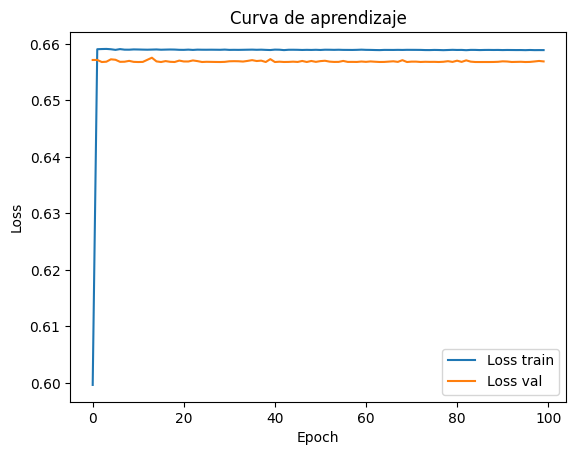

In [113]:
# Se muestra la función de coste del modelo
plt.plot(history_hotel.history['loss'], label='Loss train')
plt.plot(history_hotel.history['val_loss'], label='Loss val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step


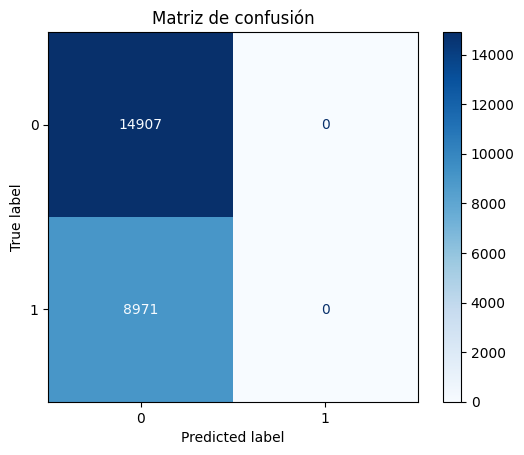

In [114]:
# Hacer predicciones y convertir probabilidades a 0/1
y_pred_prob = modelo_hotel.predict(X_test_transformed)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

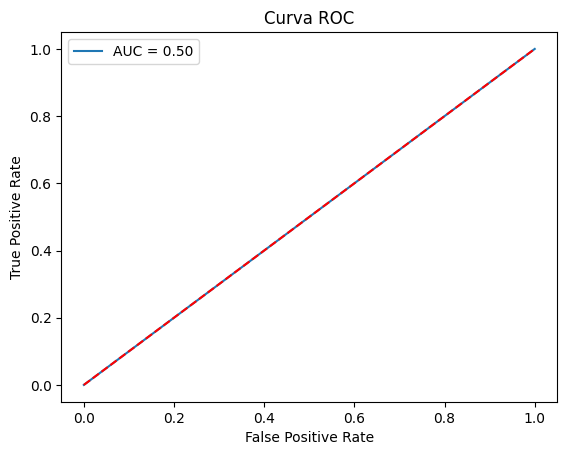

In [115]:
# Obtenemos la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()